# Classificação de Peças Metálicas com CNN

Neste notebook, será construída uma Rede Neural Convolucional para classificar peças metálicas como sem defeito ou defeituosas.

O desenvolvimento inclui ingestão das imagens, separação entre treino e validação, Data Augmentation, construção da CNN, treinamento e avaliação.

## 1. Configuração do ambiente

Nesta etapa, importamos as bibliotecas, definimos uma semente para tornar os resultados mais reproduzíveis e configuramos o caminho do dataset.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
# Mantém maior consistência entre diferentes execuções.
SEMENTE = 42

np.random.seed(SEMENTE)
tf.random.set_seed(SEMENTE)

# Identifica a raiz do projeto.
RAIZ_PROJETO = Path.cwd()

if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

PASTA_DATASET = RAIZ_PROJETO / "data" / "raw" / "casting_512x512"

print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"Raiz do projeto: {RAIZ_PROJETO}")
print(f"Dataset encontrado: {PASTA_DATASET.exists()}")
print(f"Dispositivos disponíveis: {tf.config.list_physical_devices()}")

Python: 3.13.12
TensorFlow: 2.21.0
Raiz do projeto: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn
Dataset encontrado: True
Dispositivos disponíveis: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Ingestão e divisão do dataset

O TensorFlow carregará automaticamente as imagens a partir das pastas das classes. O conjunto será dividido em 80% para treinamento e 20% para validação.

As imagens serão redimensionadas para 128 × 128 pixels, reduzindo o custo computacional do treinamento sem alterar sua proporção quadrada.

In [3]:
ALTURA_IMAGEM = 128
LARGURA_IMAGEM = 128
TAMANHO_LOTE = 32
PERCENTUAL_VALIDACAO = 0.20

# A ordem define os rótulos: OK = 0 e Defeituosa = 1.
CLASSES_DIRETORIOS = ["ok_front", "def_front"]
NOMES_CLASSES = ["OK", "Defeituosa"]

In [4]:
dataset_treino = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    labels="inferred",
    label_mode="binary",
    class_names=CLASSES_DIRETORIOS,
    validation_split=PERCENTUAL_VALIDACAO,
    subset="training",
    seed=SEMENTE,
    image_size=(ALTURA_IMAGEM, LARGURA_IMAGEM),
    batch_size=TAMANHO_LOTE,
    shuffle=True,
)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.


In [5]:
dataset_validacao = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    labels="inferred",
    label_mode="binary",
    class_names=CLASSES_DIRETORIOS,
    validation_split=PERCENTUAL_VALIDACAO,
    subset="validation",
    seed=SEMENTE,
    image_size=(ALTURA_IMAGEM, LARGURA_IMAGEM),
    batch_size=TAMANHO_LOTE,
    shuffle=True,
)

Found 1300 files belonging to 2 classes.
Using 260 files for validation.


In [6]:
print(f"Classes: {dataset_treino.class_names}")
print(f"Rótulo 0: {NOMES_CLASSES[0]}")
print(f"Rótulo 1: {NOMES_CLASSES[1]}")
print(f"Lotes de treino: {dataset_treino.cardinality().numpy()}")
print(f"Lotes de validação: {dataset_validacao.cardinality().numpy()}")

Classes: ['ok_front', 'def_front']
Rótulo 0: OK
Rótulo 1: Defeituosa
Lotes de treino: 33
Lotes de validação: 9


### 2.1 Verificação visual do carregamento

Antes do treinamento, exibimos algumas imagens de um lote para confirmar se o redimensionamento e os rótulos foram aplicados corretamente.

In [7]:
# Obtém um lote do conjunto de treinamento.
for imagens_lote, rotulos_lote in dataset_treino.take(1):
    print(f"Formato das imagens: {imagens_lote.shape}")
    print(f"Formato dos rótulos: {rotulos_lote.shape}")

Formato das imagens: (32, 128, 128, 3)
Formato dos rótulos: (32, 1)


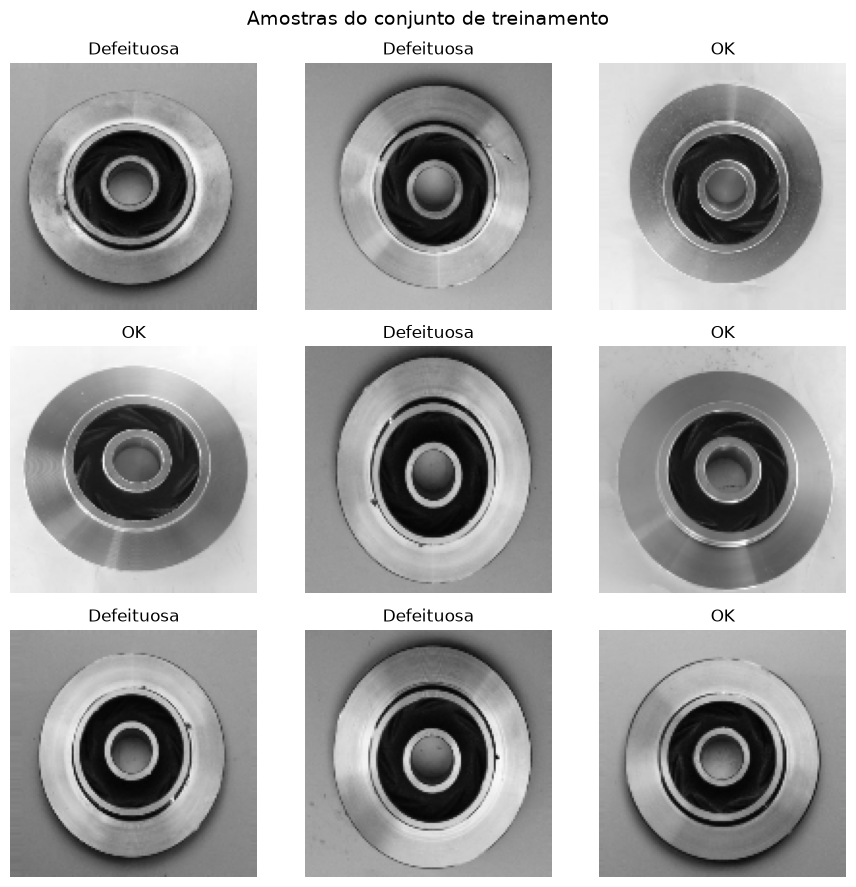

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\amostras_dataset_treino.png


In [8]:
figura, eixos = plt.subplots(3, 3, figsize=(9, 9))
eixos = eixos.flatten()

for indice, eixo in enumerate(eixos):
    # As imagens chegam como float32 entre 0 e 255.
    imagem = imagens_lote[indice].numpy().astype("uint8")
    rotulo = int(rotulos_lote[indice].numpy()[0])

    eixo.imshow(imagem)
    eixo.set_title(NOMES_CLASSES[rotulo])
    eixo.axis("off")

figura.suptitle(
    "Amostras do conjunto de treinamento",
    fontsize=14,
)

figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "amostras_dataset_treino.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Resultado da ingestão

As imagens e seus respectivos rótulos foram carregados corretamente. O redimensionamento para 128 × 128 pixels preservou o formato das peças e reduziu o custo computacional esperado durante o treinamento.

Também foram observadas variações de iluminação, contraste, escala e posicionamento. Essas diferenças serão consideradas na etapa de Data Augmentation.

## 3. Data Augmentation

O Data Augmentation cria variações das imagens durante o treinamento, simulando mudanças de posição, ângulo, aproximação, contraste e iluminação.

As transformações são aplicadas dinamicamente, sem criar novos arquivos no disco, e ajudam o modelo a aprender características mais gerais.

In [9]:
aumento_dados = models.Sequential(
    [
        layers.RandomRotation(
            factor=0.08,
            fill_mode="reflect",
            seed=SEMENTE,
        ),
        layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="reflect",
            seed=SEMENTE + 1,
        ),
        layers.RandomContrast(
            factor=0.15,
            seed=SEMENTE + 2,
        ),
        layers.RandomBrightness(
            factor=0.10,
            value_range=(0, 255),
            seed=SEMENTE + 3,
        ),
    ],
    name="data_augmentation",
)

aumento_dados.summary()

Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 3.1 Visualização das transformações

A mesma imagem será transformada várias vezes para demonstrar as variações que poderão ser apresentadas à CNN durante o treinamento.

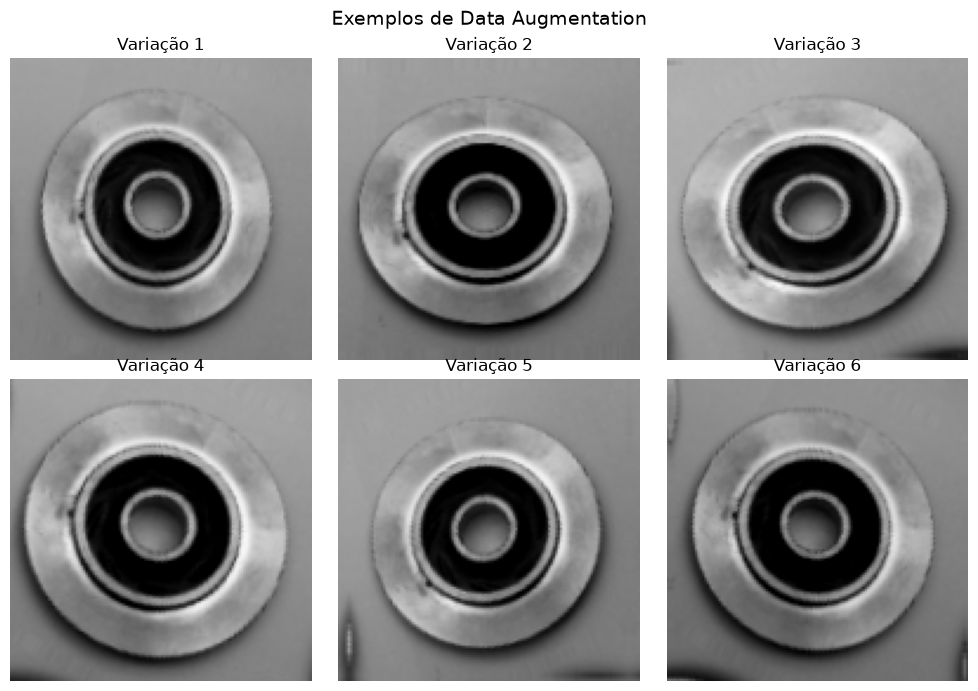

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\exemplos_data_augmentation.png


In [10]:
imagem_exemplo = imagens_lote[0]

figura, eixos = plt.subplots(2, 3, figsize=(10, 7))
eixos = eixos.flatten()

for indice, eixo in enumerate(eixos):
    imagem_aumentada = aumento_dados(
        tf.expand_dims(imagem_exemplo, axis=0),
        training=True,
    )[0]

    # Garante valores válidos para a exibição.
    imagem_aumentada = tf.clip_by_value(
        imagem_aumentada,
        0,
        255,
    )

    eixo.imshow(tf.cast(imagem_aumentada, tf.uint8))
    eixo.set_title(f"Variação {indice + 1}")
    eixo.axis("off")

figura.suptitle("Exemplos de Data Augmentation", fontsize=14)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "exemplos_data_augmentation.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Resultado do Data Augmentation

As transformações produziram variações realistas de rotação, aproximação, contraste e brilho, preservando a estrutura principal da peça e suas possíveis irregularidades.

Essas variações simulam mudanças que podem ocorrer durante a captura das imagens na linha de produção. As camadas não possuem parâmetros treináveis, pois apenas transformam os dados apresentados à CNN.

## 4. Arquitetura da Rede Neural Convolucional

A CNN utiliza blocos de convolução e pooling para extrair características visuais das imagens. As primeiras camadas aprendem padrões simples, como bordas e texturas, enquanto as camadas seguintes combinam essas informações em padrões mais complexos.

Após a extração de características, a camada `Flatten` transforma os mapas em um vetor. A camada de saída utiliza `sigmoid` para produzir a probabilidade de a peça ser defeituosa.

In [11]:
# Prepara o próximo lote enquanto o modelo processa o lote atual.
AUTOTUNE = tf.data.AUTOTUNE

dataset_treino = dataset_treino.prefetch(buffer_size=AUTOTUNE)
dataset_validacao = dataset_validacao.prefetch(buffer_size=AUTOTUNE)

In [12]:
modelo_cnn = models.Sequential(
    [
        layers.Input(
            shape=(ALTURA_IMAGEM, LARGURA_IMAGEM, 3)
        ),

        # As transformações são aplicadas somente durante o treinamento.
        aumento_dados,

        # Converte os pixels do intervalo 0–255 para 0–1.
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(
            16,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(
            32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(
            64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Transforma os mapas de características em um vetor.
        layers.Flatten(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.40),

        # Saída binária: 0 = OK e 1 = Defeituosa.
        layers.Dense(1, activation="sigmoid"),
    ],
    name="cnn_inspecao_qualidade",
)

In [13]:
modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

modelo_cnn.summary()

Model: "cnn_inspecao_qualidade"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,289 (4.09 MB)

 Trainable params: 1,072,289 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

### Análise da arquitetura

A rede reduz progressivamente as dimensões espaciais de 128 × 128 para 16 × 16, enquanto aumenta a quantidade de filtros de 16 para 64. Esse processo permite aprender características visuais em diferentes níveis de complexidade.

Após o `Flatten`, a camada densa concentra a maior parte dos 1.072.289 parâmetros do modelo. O Data Augmentation e o Dropout serão utilizados para reduzir o risco de overfitting durante o treinamento.

## 5. Preparação do treinamento

Como o dataset possui mais peças defeituosas que peças sem defeito, serão calculados pesos para equilibrar a importância das classes durante o treinamento.

Também serão utilizados callbacks para interromper o treinamento caso a validação pare de melhorar e salvar automaticamente a melhor versão do modelo.

In [14]:
# Reúne os rótulos usados no conjunto de treinamento.
rotulos_treino = np.concatenate(
    [
        rotulos.numpy().ravel()
        for _, rotulos in dataset_treino
    ]
).astype(int)

classes, quantidades = np.unique(
    rotulos_treino,
    return_counts=True,
)

total_treino = len(rotulos_treino)
quantidade_classes = len(classes)

# Classes menos frequentes recebem pesos maiores.
pesos_classes = {
    int(classe): total_treino / (quantidade_classes * quantidade)
    for classe, quantidade in zip(classes, quantidades)
}

for classe, quantidade in zip(classes, quantidades):
    print(
        f"Classe {classe} ({NOMES_CLASSES[classe]}): "
        f"{quantidade} imagens"
    )

print(f"Pesos das classes: {pesos_classes}")

Classe 0 (OK): 422 imagens
Classe 1 (Defeituosa): 618 imagens
Pesos das classes: {0: np.float64(1.2322274881516588), 1: np.float64(0.8414239482200647)}


In [15]:
PASTA_MODELOS = RAIZ_PROJETO / "models"
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

caminho_melhor_modelo = (
    PASTA_MODELOS
    / "melhor_modelo_cnn.keras"
)

callback_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1,
)

callback_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=caminho_melhor_modelo,
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

callbacks = [
    callback_early_stopping,
    callback_model_checkpoint,
]

print(f"Melhor modelo será salvo em: {caminho_melhor_modelo}")

Melhor modelo será salvo em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\models\melhor_modelo_cnn.keras


### Balanceamento e controle do treinamento

No conjunto de treino, a classe OK possui 422 imagens e a classe Defeituosa possui 618 imagens. Para compensar essa diferença, a classe menos frequente recebeu peso maior.

O `EarlyStopping` interromperá o treinamento caso a perda de validação não melhore durante quatro épocas. O `ModelCheckpoint` salvará somente a versão com menor `val_loss`.

## 6. Treinamento do modelo

A CNN será treinada por no máximo 20 épocas. Durante cada época, o modelo processará os lotes de treino e será avaliado com as imagens de validação.

O treinamento poderá terminar antes da vigésima época caso o `EarlyStopping` identifique que a perda de validação deixou de melhorar.

In [16]:
EPOCAS_MAXIMAS = 20

historico = modelo_cnn.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=EPOCAS_MAXIMAS,
    class_weight=pesos_classes,
    callbacks=callbacks,
)

Epoch 1/20


c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5788 - loss: 0.6998 - precision: 0.6705 - recall: 0.5728
Epoch 1: val_loss improved from None to 0.64450, saving model to c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\models\melhor_modelo_cnn.keras

Epoch 1: finished saving model to c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\models\melhor_modelo_cnn.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step - accuracy: 0.5788 - loss: 0.6998 - precision: 0.6705 - recall: 0.5728 - val_accuracy: 0.7192 - val_loss: 0.6445 - val_precision: 0.8309 - val_recall: 0.6933
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7106 - loss: 0.6098 - precision: 0.7856 - recall: 0.7055
Epoch 2: val_loss improved from 0.64450 to 0.56163, saving model to c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\models\melhor_modelo_cnn.keras

Epoch 2: finished saving model to c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualida

In [17]:
melhor_epoca = np.argmin(
    historico.history["val_loss"]
) + 1

menor_val_loss = min(
    historico.history["val_loss"]
)

melhor_val_accuracy = historico.history["val_accuracy"][
    melhor_epoca - 1
]

print(f"Épocas executadas: {len(historico.history['loss'])}")
print(f"Melhor época pela val_loss: {melhor_epoca}")
print(f"Menor val_loss: {menor_val_loss:.4f}")
print(f"Val_accuracy nessa época: {melhor_val_accuracy:.4f}")

Épocas executadas: 20
Melhor época pela val_loss: 19
Menor val_loss: 0.3075
Val_accuracy nessa época: 0.8462


### 6.1 Curvas de aprendizado

As curvas de treino e validação permitem avaliar a evolução do modelo. Uma diferença crescente entre elas pode indicar overfitting, enquanto trajetórias próximas sugerem melhor capacidade de generalização.

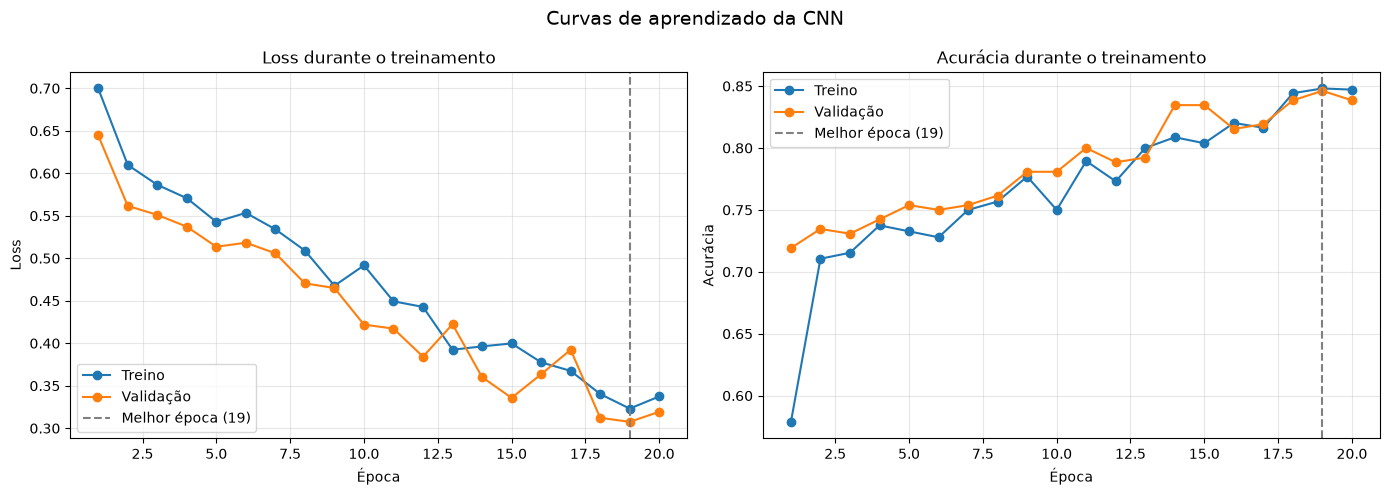

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\curvas_treinamento_cnn.png


In [18]:
metricas = historico.history
epocas = range(1, len(metricas["loss"]) + 1)

figura, eixos = plt.subplots(1, 2, figsize=(14, 5))

# Curvas da função de perda.
eixos[0].plot(
    epocas,
    metricas["loss"],
    marker="o",
    label="Treino",
)
eixos[0].plot(
    epocas,
    metricas["val_loss"],
    marker="o",
    label="Validação",
)
eixos[0].axvline(
    melhor_epoca,
    color="gray",
    linestyle="--",
    label=f"Melhor época ({melhor_epoca})",
)
eixos[0].set_title("Loss durante o treinamento")
eixos[0].set_xlabel("Época")
eixos[0].set_ylabel("Loss")
eixos[0].grid(alpha=0.3)
eixos[0].legend()

# Curvas de acurácia.
eixos[1].plot(
    epocas,
    metricas["accuracy"],
    marker="o",
    label="Treino",
)
eixos[1].plot(
    epocas,
    metricas["val_accuracy"],
    marker="o",
    label="Validação",
)
eixos[1].axvline(
    melhor_epoca,
    color="gray",
    linestyle="--",
    label=f"Melhor época ({melhor_epoca})",
)
eixos[1].set_title("Acurácia durante o treinamento")
eixos[1].set_xlabel("Época")
eixos[1].set_ylabel("Acurácia")
eixos[1].grid(alpha=0.3)
eixos[1].legend()

figura.suptitle("Curvas de aprendizado da CNN", fontsize=14)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "curvas_treinamento_cnn.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Análise do treinamento

As curvas de treino e validação evoluíram de forma próxima. A Loss diminuiu nos dois conjuntos, enquanto a acurácia aumentou progressivamente, sem ocorrer uma separação crescente entre as curvas.

Não foram identificados sinais relevantes de overfitting. Em alguns momentos, a validação apresentou desempenho superior ao treino porque o Data Augmentation e o Dropout são aplicados somente durante o treinamento.

A melhor época foi a 19, com `val_loss` de 0,3075 e `val_accuracy` de 84,62%. Na época seguinte ocorreu uma pequena piora, mas o callback restaurou os pesos da melhor época.

## 7. Avaliação final do modelo

Além da acurácia, avaliamos precisão, recall e matriz de confusão. Essas métricas ajudam a entender os tipos de erro cometidos pela CNN, especialmente a quantidade de peças defeituosas classificadas incorretamente como OK.

In [19]:
metricas_validacao = modelo_cnn.evaluate(
    dataset_validacao,
    return_dict=True,
)

for nome, valor in metricas_validacao.items():
    print(f"{nome}: {valor:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8462 - loss: 0.3075 - precision: 0.9424 - recall: 0.8037
accuracy: 0.8462
loss: 0.3075
precision: 0.9424
recall: 0.8037


In [20]:
rotulos_reais = []
probabilidades = []

# Obtém previsões e rótulos no mesmo loop para preservar sua correspondência.
for imagens, rotulos in dataset_validacao:
    probabilidades_lote = modelo_cnn.predict(
        imagens,
        verbose=0,
    ).ravel()

    probabilidades.extend(probabilidades_lote)
    rotulos_reais.extend(
        rotulos.numpy().ravel().astype(int)
    )

rotulos_reais = np.array(rotulos_reais)
probabilidades = np.array(probabilidades)

# Probabilidades iguais ou superiores a 0,5 são classificadas como defeito.
rotulos_previstos = (probabilidades >= 0.5).astype(int)

matriz_confusao = tf.math.confusion_matrix(
    rotulos_reais,
    rotulos_previstos,
    num_classes=2,
).numpy()

matriz_confusao

array([[ 89,   8],
       [ 32, 131]], dtype=int32)

In [21]:
verdadeiros_ok, falsos_defeitos, falsos_ok, verdadeiros_defeitos = (
    matriz_confusao.ravel()
)

acuracia = (
    verdadeiros_ok + verdadeiros_defeitos
) / matriz_confusao.sum()

precisao = verdadeiros_defeitos / (
    verdadeiros_defeitos + falsos_defeitos
)

recall = verdadeiros_defeitos / (
    verdadeiros_defeitos + falsos_ok
)

f1_score = 2 * precisao * recall / (
    precisao + recall
)

especificidade = verdadeiros_ok / (
    verdadeiros_ok + falsos_defeitos
)

print(f"Acurácia: {acuracia:.2%}")
print(f"Precisão: {precisao:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-score: {f1_score:.2%}")
print(f"Especificidade: {especificidade:.2%}")

Acurácia: 84.62%
Precisão: 94.24%
Recall: 80.37%
F1-score: 86.75%
Especificidade: 91.75%


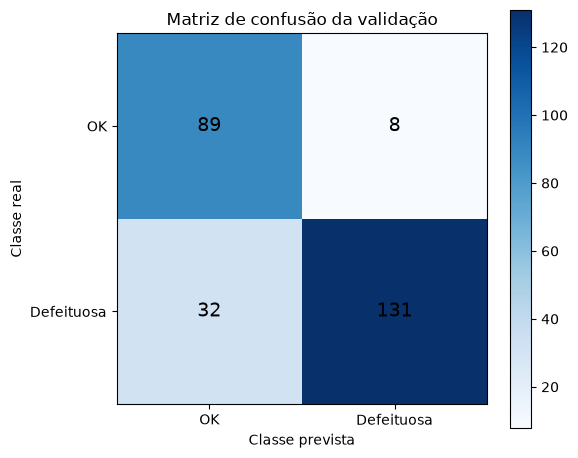

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\matriz_confusao_cnn.png


In [22]:
figura, eixo = plt.subplots(figsize=(6, 5))

imagem_matriz = eixo.imshow(
    matriz_confusao,
    cmap="Blues",
)

for linha in range(2):
    for coluna in range(2):
        eixo.text(
            coluna,
            linha,
            matriz_confusao[linha, coluna],
            ha="center",
            va="center",
            fontsize=14,
        )

eixo.set_xticks([0, 1], NOMES_CLASSES)
eixo.set_yticks([0, 1], NOMES_CLASSES)
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe real")
eixo.set_title("Matriz de confusão da validação")

figura.colorbar(imagem_matriz, ax=eixo)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "matriz_confusao_cnn.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Interpretação dos resultados

O modelo alcançou acurácia de 84,62% e F1-score de 86,75%. Das 163 peças defeituosas presentes na validação, 131 foram identificadas corretamente e 32 foram classificadas como OK.

A precisão de 94,24% demonstra que as indicações de defeito são geralmente confiáveis. Entretanto, o recall de 80,37% revela que alguns defeitos ainda não foram detectados.

Em um cenário industrial, falsos negativos são especialmente importantes, pois representam peças defeituosas aprovadas pelo sistema. Uma possível melhoria seria ajustar o limiar de decisão para aumentar o recall, mesmo que isso gere mais inspeções manuais.

### 7.1 Análise visual dos erros

AA seguir, analisamos falsos negativos e falsos positivos. Os falsos negativos são peças defeituosas classificadas como OK, enquanto os falsos positivos são peças OK classificadas como defeituosas.

Serão exibidos os erros nos quais o modelo apresentou maior confiança.

In [23]:
imagens_validacao = []
rotulos_reais = []
probabilidades = []

for imagens, rotulos in dataset_validacao:
    probabilidades_lote = modelo_cnn.predict(
        imagens,
        verbose=0,
    ).ravel()

    imagens_validacao.append(
        imagens.numpy().astype("uint8")
    )
    rotulos_reais.extend(
        rotulos.numpy().ravel().astype(int)
    )
    probabilidades.extend(probabilidades_lote)

imagens_validacao = np.concatenate(imagens_validacao)
rotulos_reais = np.array(rotulos_reais)
probabilidades = np.array(probabilidades)
rotulos_previstos = (probabilidades >= 0.5).astype(int)

print(f"Imagens reunidas: {len(imagens_validacao)}")

Imagens reunidas: 260


In [24]:
indices_falsos_negativos = np.where(
    (rotulos_reais == 1) & (rotulos_previstos == 0)
)[0]

indices_falsos_positivos = np.where(
    (rotulos_reais == 0) & (rotulos_previstos == 1)
)[0]

# Seleciona os erros com maior confiança do modelo.
indices_falsos_negativos = indices_falsos_negativos[
    np.argsort(probabilidades[indices_falsos_negativos])
][:4]

indices_falsos_positivos = indices_falsos_positivos[
    np.argsort(probabilidades[indices_falsos_positivos])[::-1]
][:4]

print(f"Falsos negativos: {sum((rotulos_reais == 1) & (rotulos_previstos == 0))}")
print(f"Falsos positivos: {sum((rotulos_reais == 0) & (rotulos_previstos == 1))}")


Falsos negativos: 32
Falsos positivos: 8


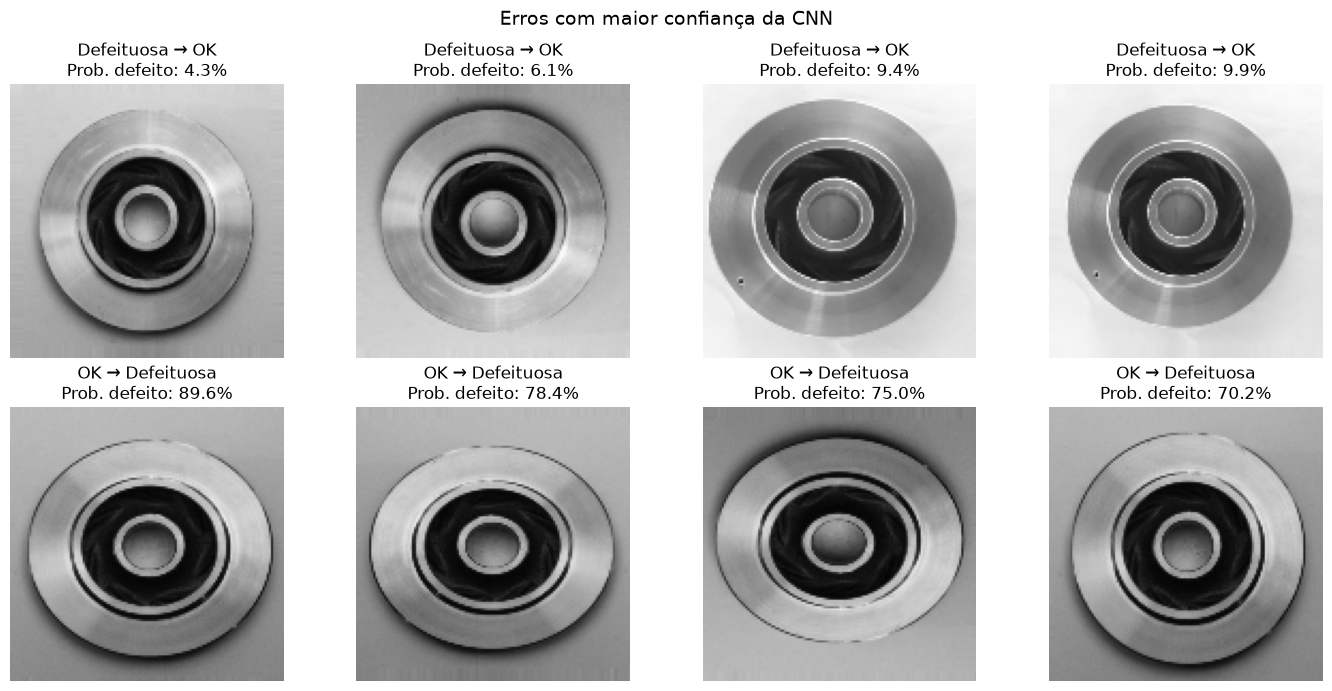

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\exemplos_erros_cnn.png


In [25]:
figura, eixos = plt.subplots(2, 4, figsize=(14, 7))

for coluna, indice in enumerate(indices_falsos_negativos):
    eixos[0, coluna].imshow(imagens_validacao[indice])
    eixos[0, coluna].set_title(
        f"Defeituosa → OK\n"
        f"Prob. defeito: {probabilidades[indice]:.1%}"
    )
    eixos[0, coluna].axis("off")

for coluna, indice in enumerate(indices_falsos_positivos):
    eixos[1, coluna].imshow(imagens_validacao[indice])
    eixos[1, coluna].set_title(
        f"OK → Defeituosa\n"
        f"Prob. defeito: {probabilidades[indice]:.1%}"
    )
    eixos[1, coluna].axis("off")

figura.suptitle("Erros com maior confiança da CNN", fontsize=14)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "exemplos_erros_cnn.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Interpretação dos erros

Os falsos negativos apresentam defeitos pequenos e localizados, alguns com baixo contraste em relação à superfície. O redimensionamento para 128 × 128 pixels pode reduzir a visibilidade dessas características.

Nos falsos positivos, variações de iluminação, sombras e contornos mais intensos podem ter sido confundidos com irregularidades estruturais.

Como possíveis melhorias, podem ser avaliados o uso de imagens com maior resolução, o ajuste do limiar de decisão e arquiteturas mais profundas ou pré-treinadas.